In [ ]:
import os
from tqdm.notebook import tqdm # Use tqdm.notebook for better display in Jupyter

def create_dummy_gt(image_folder_path, output_gt_file_path, dummy_label="DUMMY_LABEL", image_extensions=None):
    """
    Scans an image folder and its subdirectories for image files and creates a
    gt.txt file with a dummy label for each found image.

    Args:
        image_folder_path (str): Path to the root folder containing images.
        output_gt_file_path (str): Path where the dummy gt.txt will be saved.
        dummy_label (str, optional): The label to use for all images.
                                     Defaults to "DUMMY_LABEL".
        image_extensions (list, optional): List of image file extensions to look for
                                           (case-insensitive).
                                           Defaults to ['.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif', '.webp'].
    """
    if image_extensions is None:
        image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif', '.webp']
    # Ensure extensions are lowercase for case-insensitive comparison
    image_extensions = [ext.lower() for ext in image_extensions]

    if not os.path.isdir(image_folder_path):
        print(f"Error: Image folder not found at '{image_folder_path}'")
        return False # Indicate failure

    # Ensure the output directory exists
    output_dir = os.path.dirname(output_gt_file_path)
    if output_dir and not os.path.exists(output_dir):
        try:
            os.makedirs(output_dir)
            print(f"Created output directory: {output_dir}")
        except OSError as e:
            print(f"Error creating output directory {output_dir}: {e}")
            return False # Indicate failure


    found_images_count = 0
    try:
        with open(output_gt_file_path, 'w', encoding='utf-8') as f_gt:
            print(f"Scanning '{image_folder_path}' for images...")
            # Walk through the directory and its subdirectories
            for root, _, files in tqdm(os.walk(image_folder_path), desc="Scanning folders"):
                for filename in files:
                    # Check if the file has one of the specified image extensions
                    if os.path.splitext(filename)[1].lower() in image_extensions:
                        full_path = os.path.join(root, filename)
                        # Get the relative path from the image_folder_path
                        relative_path = os.path.relpath(full_path, image_folder_path)
                        # Normalize path separators for consistency (use forward slashes)
                        relative_path = relative_path.replace('\\', '/')
                        
                        f_gt.write(f"{relative_path}\t{dummy_label}\n")
                        found_images_count += 1
    except IOError as e:
        print(f"Error writing to GT file {output_gt_file_path}: {e}")
        return False # Indicate failure
    
    if found_images_count > 0:
        print(f"\nSuccessfully created dummy gt.txt at '{output_gt_file_path}' with {found_images_count} entries.")
    else:
        print(f"\nNo images found in '{image_folder_path}' with the specified extensions.")
        print(f"An empty gt.txt (or a file with 0 entries) was created at '{output_gt_file_path}'.")
    return True # Indicate success

In [ ]:
# --- Configuration ---
my_image_folder = "/ssd_scratch/cvit/lalitha/parseq/data/test/internet_data/test"  # REPLACE with your actual image folder path
my_output_gt_file = "/ssd_scratch/cvit/lalitha/parseq/data/test/internet_data/test/gt.txt"    # REPLACE with your desired output gt.txt path
my_dummy_label = "PLEASE_TRANSCRIBE"
my_extensions = ['.jpg', '.png', '.jpeg'] # Customize if needed

# --- Call the function ---
success = create_dummy_gt(
    image_folder_path=my_image_folder,
    output_gt_file_path=my_output_gt_file,
    dummy_label=my_dummy_label,
    image_extensions=my_extensions
)

if success:
    print("Dummy GT file creation process finished successfully.")
else:
    print("Dummy GT file creation process encountered an error.")

In [1]:
import os
import shutil
#get out the images from subfolders and rename the duplicates 
# Set the parent directory where subfolders are located
parent_dir = '/ssd_scratch/cvit/lalitha/unlabelled_kannada'  # <- change this

# Allowed image extensions
image_extensions = {'.jpg', '.jpeg', '.png', '.webp', '.gif'}

# Traverse all subdirectories
for root, dirs, files in os.walk(parent_dir, topdown=False):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext in image_extensions:
            src_path = os.path.join(root, file)
            dst_path = os.path.join(parent_dir, file)

            # If destination file exists, add a suffix to avoid overwrite
            if os.path.exists(dst_path):
                base, ext = os.path.splitext(file)
                i = 1
                while True:
                    new_name = f"{base}_{i}{ext}"
                    new_dst_path = os.path.join(parent_dir, new_name)
                    if not os.path.exists(new_dst_path):
                        dst_path = new_dst_path
                        break
                    i += 1

            shutil.move(src_path, dst_path)

# Remove empty subdirectories
for root, dirs, files in os.walk(parent_dir, topdown=False):
    for dir in dirs:
        dir_path = os.path.join(root, dir)
        if not os.listdir(dir_path):  # Check if empty
            os.rmdir(dir_path)


splitting dataset into train and test unlabelled 80:20

In [2]:
import os
import shutil
import random
from pathlib import Path

def split_images(input_dir, output_dir, split_ratio=0.9, seed=42):
    """
    Splits images in input_dir into train and test folders in output_dir.
    
    Parameters:
    - input_dir: Path to input folder containing images.
    - output_dir: Path where 'train' and 'test' folders will be created.
    - split_ratio: Ratio of training images. Default is 0.8.
    - seed: Random seed for reproducibility.
    """
    random.seed(seed)
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)

    # Get all image files (you can add more extensions if needed)
    image_files = [f for f in input_dir.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']]
    image_files.sort()  # For consistency across platforms
    random.shuffle(image_files)

    split_idx = int(len(image_files) * split_ratio)
    train_files = image_files[:split_idx]
    test_files = image_files[split_idx:]

    train_dir = output_dir / 'train'
    test_dir = output_dir / 'test'
    train_dir.mkdir(parents=True, exist_ok=True)
    test_dir.mkdir(parents=True, exist_ok=True)

    # Copy files
    for file in train_files:
        shutil.copy(file, train_dir / file.name)
    for file in test_files:
        shutil.copy(file, test_dir / file.name)

    print(f"✅ Done: {len(train_files)} images in 'train', {len(test_files)} in 'test'.")


# Example usage
input_path = '/ssd_scratch/cvit/lalitha/unlabelled_kannada'          # Replace with your actual input folder path
output_path = '/ssd_scratch/cvit/lalitha/split_data'       # Replace with desired output location

split_images(input_path, output_path, split_ratio=0.9, seed=42)


✅ Done: 65990 images in 'train', 7333 in 'test'.


confidence distribution graphs and code

Successfully loaded 12870 records from the file.

Analyzing 12869 valid records.

Image Distribution across Confidence Intervals:
confidence_bin
(-0.001, 0.1]        0
(0.1, 0.2]           3
(0.2, 0.3]           7
(0.3, 0.4]          34
(0.4, 0.5]          50
(0.5, 0.6]         148
(0.6, 0.7]         138
(0.7, 0.8]         172
(0.8, 0.9]         264
(0.9, 1.0]       12053
Name: count, dtype: int64


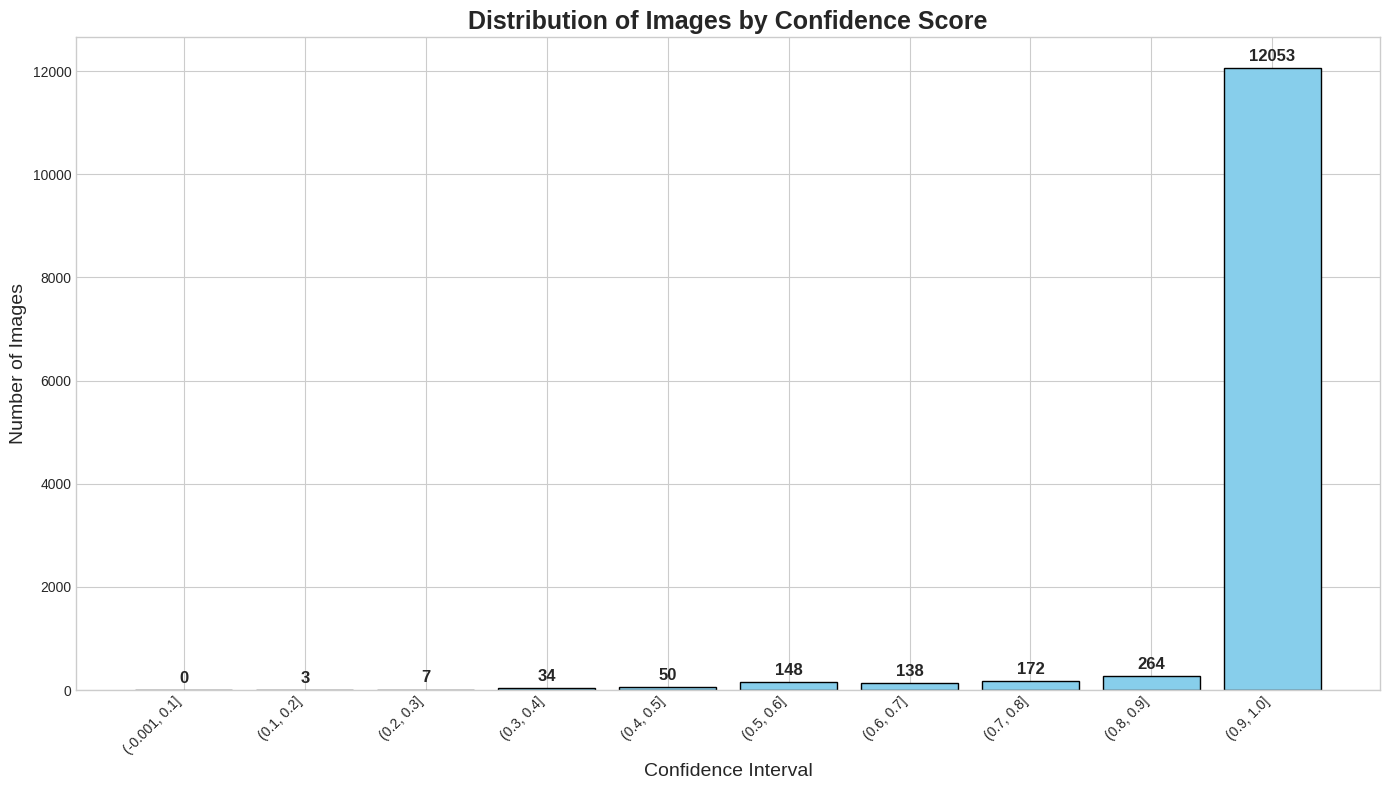

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Configuration ---
# Please change this path to point to your actual confidence_scores.txt file.
file_path = '/ssd_scratch/cvit/lalitha/confidence_txts/iiit-indic-hw-test.txt'

# --- 2. Load the Data ---
try:
    # Load the data from the text file.
    # We assume tab-separated values and no header row.
    df = pd.read_csv(
        file_path,
        sep='\t',
        header=None,
        names=['image_index', 'ground_truth', 'prediction', 'confidence']
    )
    print(f"Successfully loaded {len(df)} records from the file.")
    
    # =========================================================================
    # === FIX IS HERE: Clean the 'confidence' column to ensure it's numeric ===
    # =========================================================================
    
    # Step A: Convert the 'confidence' column to a numeric type.
    # `errors='coerce'` is the key: it will turn any non-numeric string 
    # (like 'N/A' or '1.000 I') into NaN (Not a Number).
    df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce')
    
    # Step B: Report and drop any rows that had bad data.
    original_count = len(df)
    # .dropna() removes rows containing NaN values from the specified column.
    df.dropna(subset=['confidence'], inplace=True)
    cleaned_count = len(df)
    
    if original_count > cleaned_count:
        dropped_rows = original_count - cleaned_count
        print(f"\nWARNING: Dropped {dropped_rows} rows due to non-numeric or missing confidence scores.")
    print(f"Analyzing {cleaned_count} valid records.")
    # =========================================================================
    # === END OF FIX                                                        ===
    # =========================================================================


    # --- 3. Create Confidence Bins ---
    # Define the 10 intervals (bins) from 0.0 to 1.0.
    bins = np.linspace(0, 1, 11)
    
    # This will now work because the 'confidence' column is clean.
    df['confidence_bin'] = pd.cut(df['confidence'], bins=bins, include_lowest=True)

    # --- 4. Calculate the Distribution ---
    distribution = df['confidence_bin'].value_counts().sort_index()
    
    print("\nImage Distribution across Confidence Intervals:")
    print(distribution)

    # --- 5. Plot the Distribution ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(14, 8))

    bars = ax.bar(
        distribution.index.astype(str), 
        distribution.values, 
        color='skyblue',
        edgecolor='black'
    )

    # --- 6. Add Counts on Top of Each Bar ---
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{int(height)}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )

    # --- 7. Final Touches for the Plot ---
    ax.set_title('Distribution of Images by Confidence Score', fontsize=18, fontweight='bold')
    ax.set_xlabel('Confidence Interval', fontsize=14)
    ax.set_ylabel('Number of Images', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    plt.show()

except FileNotFoundError:
    print(f"ERROR: The file was not found at '{file_path}'.")
    print("Please make sure the path is correct and the file exists.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")